End to End Implementation of First CNN Arch from dataset to model Arch to Training to Evaluation
(Some Modification wrt to of Optimizer done)

### Set Up

In [20]:
import os
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
model_name = "model/firstcnn.keras"

### The Dataset (2)

> Info : We use MNIST, which is almost same as what paper used.

> Paper : The database used to train and test the network consists of 9298 segmented numerals digitized from handwritten zip codes
that appeared on U.S. mail passing through the Buffalo, NY post office.
7291 examples are used for training the network and 2007 are used for testing the generalization performance.
One important feature of this data base is that both the training set and the testing set contain numerous examples that are
ambiguous, unclassifiable, or even misclassified.

> Me : We use 60000 Training data and 10000 Test data (Paper used 7291 for Training and 2007 for Testing from their data)
       And it is well know MNIST does have few ambiguous and misclassified images, so it does reflects the paper experiment there.

> Paper : The size of a digit image varies but is typically around 40 by 60 pixels.
A linear transformation is then applied to make the image fit in a 16 by 16 pixel image.
This transformation preserves the aspect ratio of the character ...,
The gray levels of each image are scaled and translated to fall within the range -1 to 1.

> Me : Our MNIST data is of 28 by 28 fixed, We will use 28x28 itself. Our grayscal image raanges from 0 to 255 as gray level, we will scale it to -1 to 1 as done in paper



In [22]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

Label :  5
Image : 


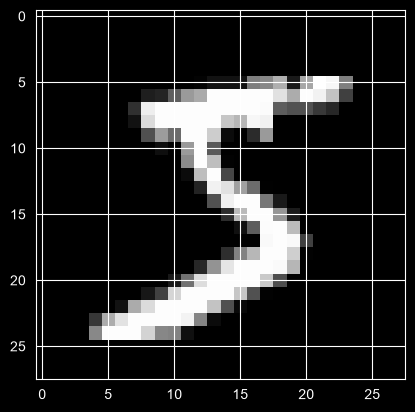

In [23]:
index = 0
print("Label : ", train_labels[index])
print("Image : ")
plt.imshow(train_images[index], cmap="gray")
plt.show()

In [24]:
train_images[0].min(), train_images[0].max()

(np.uint8(0), np.uint8(255))

In [25]:
train_images = np.expand_dims(train_images, axis=-1).astype(np.float32)
test_images = np.expand_dims(test_images, axis=-1).astype(np.float32)
train_images = tf.image.resize(train_images, [16, 16]).numpy()
test_images = tf.image.resize(test_images, [16, 16]).numpy()
train_images.shape, test_images.shape

((60000, 16, 16, 1), (10000, 16, 16, 1))

Label :  5
Image : 


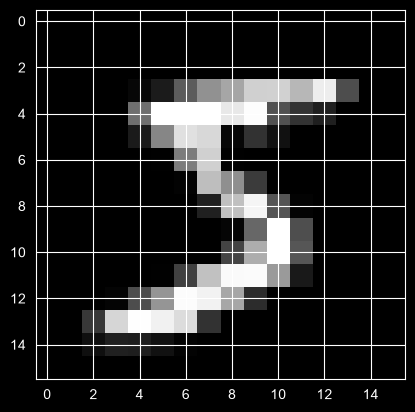

In [26]:
index = 0
print("Label : ", train_labels[index])
print("Image : ")
plt.imshow(train_images[index], cmap="gray")
plt.show()

In [27]:
train_images = (train_images - 127.5)/127.5
test_images = (test_images - 127.5)/127.5
train_images[0].min(), train_images[0].max()

(np.float32(-1.0), np.float32(0.9843137))

Label :  5
Image : 


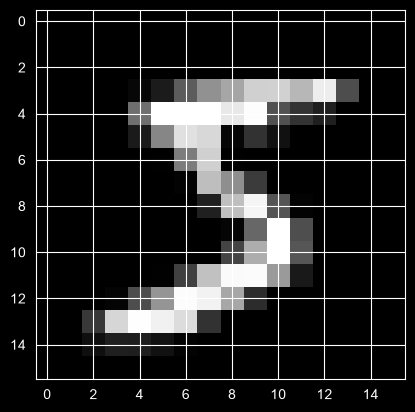

In [28]:
index = 0
print("Label : ", train_labels[index])
print("Image : ")
plt.imshow(train_images[index], cmap="gray")
plt.show()

In [29]:
train_labels, train_labels.min(), train_labels.max()

(array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8),
 np.uint8(0),
 np.uint8(9))

In [30]:
def create_tanh_targets(labels, num_classes=10):
    targets = np.full((len(labels), num_classes), -0.8, dtype=np.float32)
    targets[np.arange(len(labels)), labels] = 0.8
    return targets

train_labels = create_tanh_targets(train_labels)
test_labels = create_tanh_targets(test_labels)

In [31]:
train_labels, train_labels.min(), train_labels.max()

(array([[-0.8, -0.8, -0.8, ..., -0.8, -0.8, -0.8],
        [ 0.8, -0.8, -0.8, ..., -0.8, -0.8, -0.8],
        [-0.8, -0.8, -0.8, ..., -0.8, -0.8, -0.8],
        ...,
        [-0.8, -0.8, -0.8, ..., -0.8, -0.8, -0.8],
        [-0.8, -0.8, -0.8, ..., -0.8, -0.8, -0.8],
        [-0.8, -0.8, -0.8, ..., -0.8,  0.8, -0.8]],
       shape=(60000, 10), dtype=float32),
 np.float32(-0.8),
 np.float32(0.8))

### Model Architecture (3)

In [32]:
inputs = keras.Input(shape=(16, 16, 1))
x = keras.layers.Conv2D(filters=12, kernel_size=5, strides=2, padding="same", activation="tanh", name="H1")(inputs)
x = keras.layers.Conv2D(filters=12, kernel_size=5, strides=2, padding="same", activation="tanh", name="H2")(x)
x = keras.layers.Flatten(name="flatten")(x)
x = keras.layers.Dense(30, activation="tanh", name="H3")(x)
outputs = keras.layers.Dense(10, activation="tanh", name="output")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H1 (Conv2D)                     │ (None, 8, 8, 12)       │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H2 (Conv2D)                     │ (None, 4, 4, 12)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H3 (Dense)                      │ (None, 30)             │         5,790 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,024 (39.16 KB)

 Trainable params: 10,024 (39.16 KB)

 Non-trainable params: 0 (0.00 B)

Notes :

**1. Layer H1 (Keras: 312 params | Paper: 1,068 params)**
* **Keras:** 12 filters × (5×5 kernel × 1 input channel) = 300 weights. Add 1 shared bias per filter (12 biases) = **312 parameters**.
* **Paper:** 300 weights, plus *unshared biases* for every single unit in the 8×8 feature maps (12 maps × 64 units = 768 biases). 300 + 768 = **1,068 parameters**.


**2. Layer H2 (Keras: 3,612 params | Paper: 2,592 params)**

* **Keras:** 12 filters × (5×5 kernel × 12 input channels from H1) = 3,600 weights. Add 1 shared bias per filter (12 biases) = **3,612 parameters**.
* **Paper:** Intentionally restricted the connections so each H2 unit only looked at 8 of the 12 H1 maps (12 filters × 5×5 kernel × 8 maps = 2,400 weights). Add 192 unshared biases (12 maps × 16 units) = **2,592 parameters**.


**3. Layer H3 (Keras: 5,790 params | Paper: 5,790 params)**

* **Both:** A standard fully connected layer. 192 flattened H2 units × 30 units = 5,760 weights + 30 biases = **5,790 parameters**.


**4. Output Layer (Keras: 310 params | Paper: 310 params)**

* **Both:** A standard fully connected layer. 30 H3 units × 10 output classes = 300 weights + 10 biases = **310 parameters**.



**Total:**

* **Keras:** 312 + 3,612 + 5,790 + 310 = **10,024 parameters**.
* **1989 Paper:** 1,068 + 2,592 + 5,790 + 310 = **9,760 parameters**.

I Hope this difference means insignificant in experiment

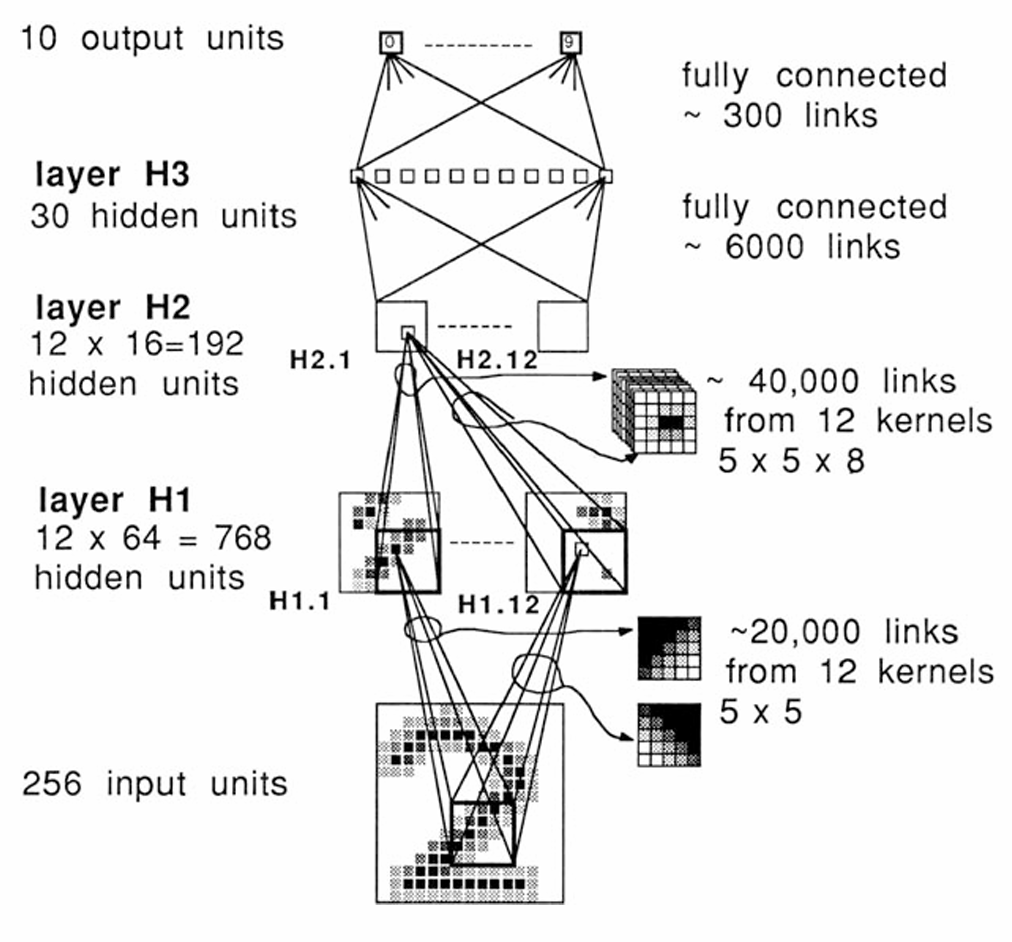

### Training/Learning (6)

Paper : The nonlinear function used at each node was a scaled hyperbolic tangent.
The target values for the output units were chosen within the quasilinear range of the sigmoid.

We : Used Tanh at all layers including output layer as paper described


Paper : Before training, the weights were initialized with random values using a uniform distribution between -2.4/Fi and 2.4/Fi where F, is the number of inputs (fan-in) of the unit to which the connection belongs.

We : We leave all Weight Initialization to keras library default


Paper : The weights were updated according to the so-called stochastic gradient or "on-line" procedure

We : Used Same, SGD

In [33]:
# Optimizer
optimizer = keras.optimizers.SGD(learning_rate=0.01) # Paper usage (Param, we set)

In [34]:
torch.backends.cudnn.benchmark = True
if os.path.exists(model_name): # Mechanism to continue training model from where it stopped
    model = keras.models.load_model(model_name)
else:
    model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H1 (Conv2D)                     │ (None, 8, 8, 12)       │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H2 (Conv2D)                     │ (None, 4, 4, 12)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H3 (Dense)                      │ (None, 30)             │         5,790 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,026 (39.17 KB)

 Trainable params: 10,024 (39.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [35]:
checkpoint = keras.callbacks.ModelCheckpoint(model_name, monitor="val_accuracy", save_best_only=True)

In [36]:
# Training : Paper used 23 Epochs. We Used Same, 10 Sec per Epoch. Took ~4 min (Paper claims 3 days on a Sun workstation in 1989)
history = model.fit(train_images, train_labels, validation_split=0.2, epochs=23, callbacks=[checkpoint])
df = pd.DataFrame(history.history)
df.to_csv("firstcnn.csv")

Epoch 1/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9630 - loss: 0.0262 - val_accuracy: 0.9637 - val_loss: 0.0255
Epoch 2/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9630 - loss: 0.0260 - val_accuracy: 0.9641 - val_loss: 0.0254
Epoch 3/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9636 - loss: 0.0257 - val_accuracy: 0.9643 - val_loss: 0.0251
Epoch 4/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9640 - loss: 0.0255 - val_accuracy: 0.9653 - val_loss: 0.0250
Epoch 5/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9643 - loss: 0.0253 - val_accuracy: 0.9646 - val_loss: 0.0247
Epoch 6/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9645 - loss: 0.0251 - val_accuracy: 0.9652 - val_loss: 0.0246
Epoch 7/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9646 - loss: 0.0249 - val_accuracy: 0.9654 - val_loss: 0.0243
Epoch 8/23
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9647 - loss: 0.0247 -

### Evaluation Plots

In [37]:
history = pd.read_csv("firstcnn.csv")

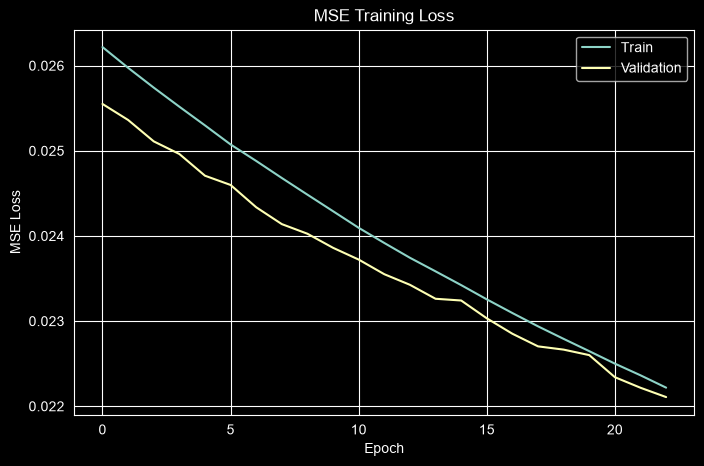

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MSE Training Loss")
plt.legend()
plt.show()

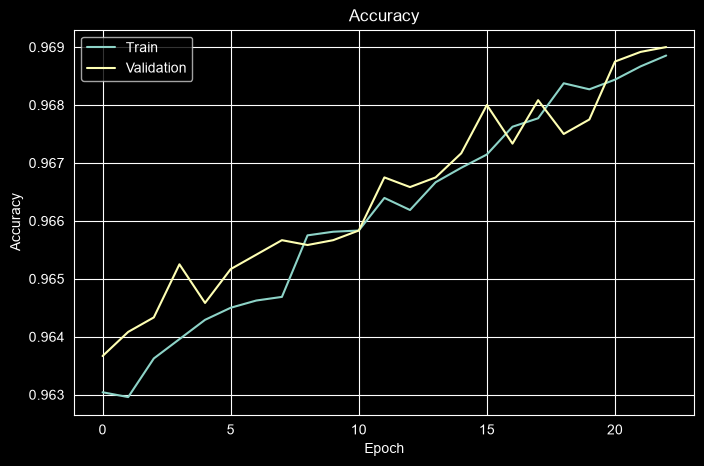

In [39]:
plt.figure(figsize=(8,5))
plt.plot(history["accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

### Inference & Evaluation

In [40]:
model = keras.models.load_model(model_name)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H1 (Conv2D)                     │ (None, 8, 8, 12)       │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H2 (Conv2D)                     │ (None, 4, 4, 12)       │         3,612 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ H3 (Dense)                      │ (None, 30)             │         5,790 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,026 (39.17 KB)

 Trainable params: 10,024 (39.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [41]:
loss, accuracy = model.evaluate(test_images, test_labels)
print("Loss :", loss, "Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9681 - loss: 0.0220
Loss : 0.022023290395736694 Accuracy : 0.9681000113487244


END